# Сведение задачи оптимального управления к задаче минимизации функции многих переменных

Работаем с задачей, постановка которой приведена в документе Task3-general.pdf
Сводим её к задаче с терминальным функционалом, как показано в Task3-transform.pdf

Проводим полную дискретизацию, сводя к задаче минимизации функции многих переменных, как показано в Task3-discretization.pdf



Применяем эту схему для решения задачи:

$J := y(t_N)\to\min$

$\dot x = u$,
$\dot y = x^2$,
$u(t) \ge -1, u(t) \le 1$

$x(t_0)=x_0$ -- параметр,
$x(t_1)=x_1$ -- параметр,
$y(t_0)=0$

Применяем метод штрафных функций.

На выходе: точечные графики $x(t_i), y(t_i), u(t_i)$.
Мы ожидаем, что получится траектория, на которой x(t) как можно быстрее доходит до $0$ и потом доходит до $x(t_1)$.

Дискретизуем отрезок $[t_0,t_1]$ точками $t_i=t_0+i\,dt$, где $dt=(t_1-t_0)/N$.

Ищем значения

$$x_0,\ldots,x_N,\qquad y_0,\ldots,y_N,\qquad u_0,\ldots,u_{N-1}.$$

По явной схеме Эйлера получаем ограничения

$$x_{i+1}=x_i+dt\,u_i,\qquad y_{i+1}=y_i+dt\,x_i^2.$$

Так как используем метод штрафов, минимизируем не только $y_N$, но и добавляем штрафы за нарушение динамики, краевых условий и ограничений $-1\le u_i\le 1$.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from pathlib import Path

Задаём параметры задачи и строим сетку.

In [18]:
t0 = 0.0
t1 = 4.0

x_left = 2.0
x_right = -1.0

N = 60
dt = (t1 - t0) / N
t = np.linspace(t0, t1, N + 1)

if t1 <= t0:
    raise ValueError("Должно быть t1 > t0")

if abs(x_right - x_left) > t1 - t0:
    raise ValueError("При |u| <= 1 нельзя перейти из x_left в x_right за это время")

Собираем начальное приближение. Берём линейную траекторию $x$, управление из разностей и соответствующее $y$.

In [19]:
x_initial = np.linspace(x_left, x_right, N + 1)
u_initial = np.diff(x_initial) / dt

y_initial = np.zeros(N + 1)
y_initial[1:] = np.cumsum(dt * x_initial[:-1] ** 2)

z = np.r_[x_initial, y_initial, u_initial]

Вектор переменных храним в одном массиве: сначала все значения $x_i$, потом все $y_i$, потом все $u_i$.

Ниже записана штрафная целевая функция

$$\Phi_\rho = y_N + \rho\,P,$$

где $P$ -- сумма квадратов всех нарушений.

In [20]:
def phi(z, rho):
    x = z[:N + 1]
    y = z[N + 1:2 * N + 2]
    u = z[2 * N + 2:]

    x_equation = x[1:] - x[:-1] - dt * u
    y_equation = y[1:] - y[:-1] - dt * x[:-1] ** 2

    u_above = np.maximum(u - 1.0, 0.0)
    u_below = np.maximum(-1.0 - u, 0.0)

    penalty = 0.0
    penalty += np.sum(x_equation ** 2)
    penalty += np.sum(y_equation ** 2)
    penalty += (x[0] - x_left) ** 2
    penalty += (x[-1] - x_right) ** 2
    penalty += y[0] ** 2
    penalty += np.sum(u_above ** 2)
    penalty += np.sum(u_below ** 2)

    return y[-1] + rho * penalty

Решаем несколько задач минимизации подряд. После каждого значения $\rho$ используем найденную точку как начальное приближение для следующего шага.

In [21]:
rho_values = [1, 10, 100, 1000, 10000]
rows = []

for rho in rho_values:
    result = minimize(
        phi,
        z,
        args=(rho,),
        method="L-BFGS-B",
        options={"maxiter": 800, "ftol": 1e-12},
    )

    z = result.x

    x = z[:N + 1]
    y = z[N + 1:2 * N + 2]
    u = z[2 * N + 2:]

    x_equation = x[1:] - x[:-1] - dt * u
    y_equation = y[1:] - y[:-1] - dt * x[:-1] ** 2
    u_above = np.maximum(u - 1.0, 0.0)
    u_below = np.maximum(-1.0 - u, 0.0)

    rows.append(
        {
            "rho": rho,
            "success": result.success,
            "J = y_N": y[-1],
            "max |x equation|": np.max(np.abs(x_equation)),
            "max |y equation|": np.max(np.abs(y_equation)),
            "max u violation": max(np.max(u_above), np.max(u_below)),
        }
    )

report = pd.DataFrame(rows)
report

,rho,success,J = y_N,max |x equation|,max |y equation|,max u violation
0,1,False,-31.312270,0.301341,0.585626,0.018896
1,10,False,0.128274,0.117629,0.084927,0.023828
2,100,False,0.818505,0.061413,0.036398,0.015575
3,1000,False,2.667631,0.016814,0.009504,0.001912
4,10000,False,2.645883,0.014039,0.005533,0.000924


Достаём найденные массивы из итогового вектора и строим требуемые точечные графики.

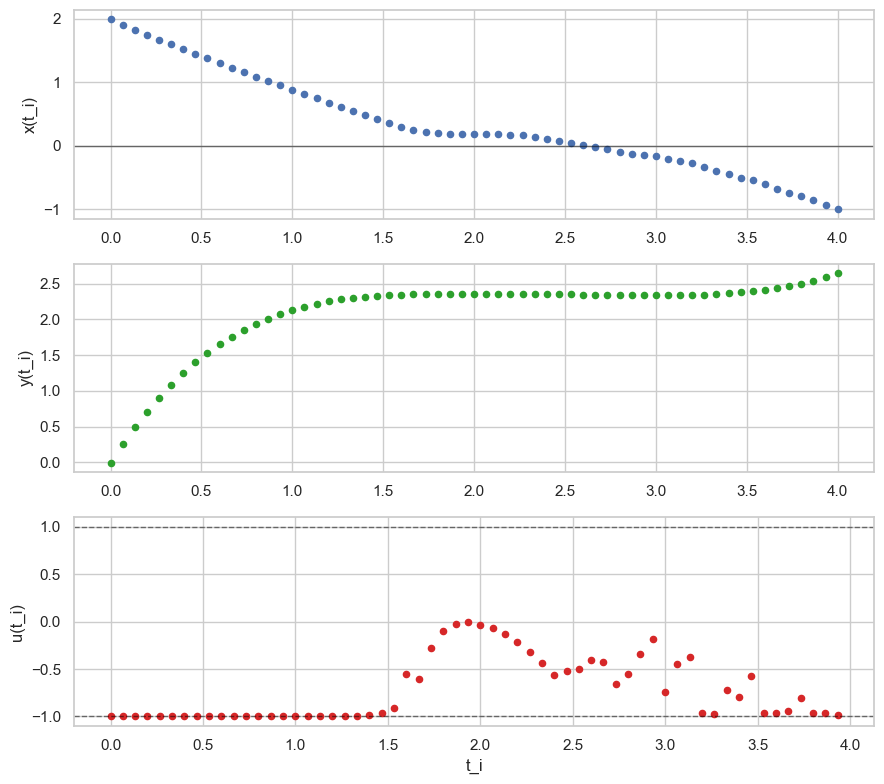

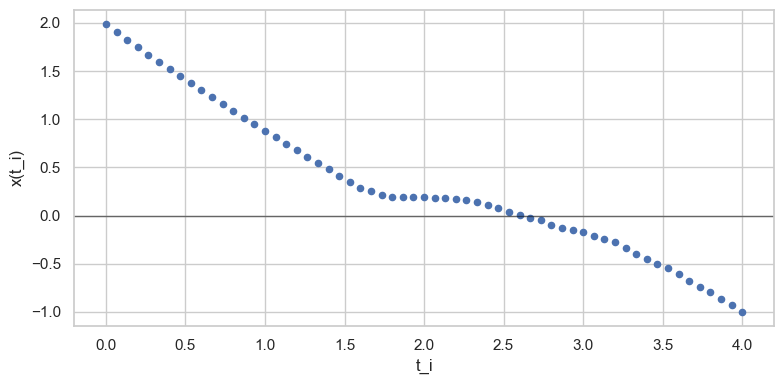

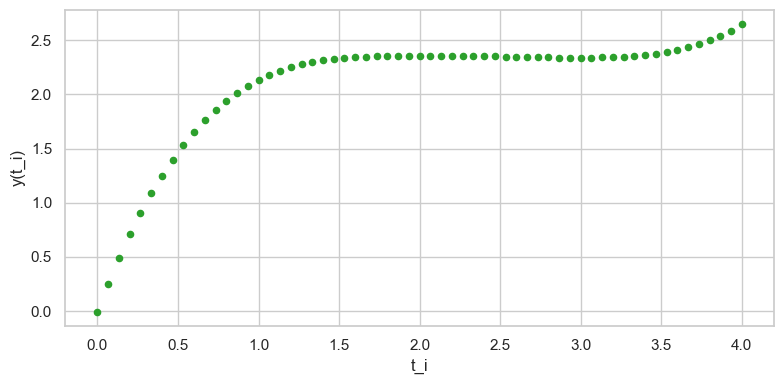

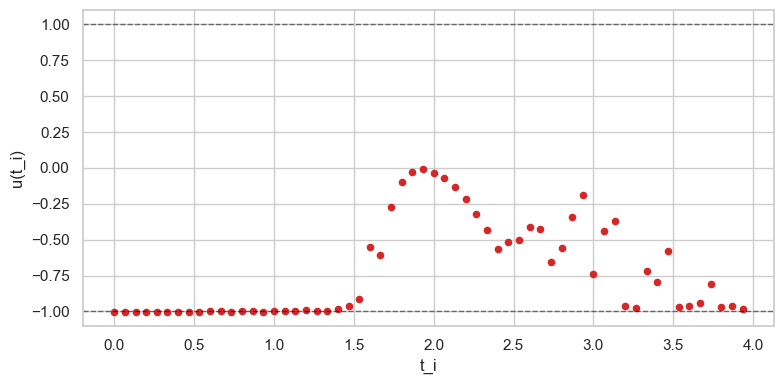

In [22]:
x = z[:N + 1]
y = z[N + 1:2 * N + 2]
u = z[2 * N + 2:]

output_dir = Path("materials")
output_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(9, 8))

axes[0].scatter(t, x, s=20)
axes[0].axhline(0.0, color="black", linewidth=1.0, alpha=0.5)
axes[0].set_ylabel("x(t_i)")

axes[1].scatter(t, y, s=20, color="tab:green")
axes[1].set_ylabel("y(t_i)")

axes[2].scatter(t[:-1], u, s=20, color="tab:red")
axes[2].axhline(1.0, color="black", linewidth=1.0, linestyle="--", alpha=0.5)
axes[2].axhline(-1.0, color="black", linewidth=1.0, linestyle="--", alpha=0.5)
axes[2].set_xlabel("t_i")
axes[2].set_ylabel("u(t_i)")

plt.tight_layout()
fig.savefig(output_dir / "solution_plot.png", dpi=300, bbox_inches="tight")

fig_x, ax_x = plt.subplots(figsize=(8, 4))
ax_x.scatter(t, x, s=20)
ax_x.axhline(0.0, color="black", linewidth=1.0, alpha=0.5)
ax_x.set_xlabel("t_i")
ax_x.set_ylabel("x(t_i)")
fig_x.tight_layout()
fig_x.savefig(output_dir / "x_plot.png", dpi=300, bbox_inches="tight")

fig_y, ax_y = plt.subplots(figsize=(8, 4))
ax_y.scatter(t, y, s=20, color="tab:green")
ax_y.set_xlabel("t_i")
ax_y.set_ylabel("y(t_i)")
fig_y.tight_layout()
fig_y.savefig(output_dir / "y_plot.png", dpi=300, bbox_inches="tight")

fig_u, ax_u = plt.subplots(figsize=(8, 4))
ax_u.scatter(t[:-1], u, s=20, color="tab:red")
ax_u.axhline(1.0, color="black", linewidth=1.0, linestyle="--", alpha=0.5)
ax_u.axhline(-1.0, color="black", linewidth=1.0, linestyle="--", alpha=0.5)
ax_u.set_xlabel("t_i")
ax_u.set_ylabel("u(t_i)")
fig_u.tight_layout()
fig_u.savefig(output_dir / "u_plot.png", dpi=300, bbox_inches="tight")

In [23]:
import sys
print(sys.executable)

/Users/zuha/Desktop/FKI/4 курс 2025-2026/8 семестр/Optimization Methods/OptMet/bin/python3
